Creates Figure S5

In [1]:
#load packages needed in this notebook
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
from eofs.standard import Eof
import regionmask
import cartopy.crs as ccrs
from matplotlib import pyplot as PP
import copy
import matplotlib as mpl
import matplotlib.patches as mpatches
from cartopy.util import add_cyclic_point

ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/home/nmaher/.conda/envs/clara/share/proj failed


In [2]:
#define models and start years
models=['CESM2','CESM1-LE','ACCESS-SSP370','CanESM5-SSP370','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']
models_title=['CESM2','CESM1','ACCESS','CanESM5','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']

#tell me when the start year is 
syear=[1850,1920,1850,1850,1921,1850,1850,1850]
#offset=1920-syear

#load lon lat should be same for all models
outputdira='/glade/campaign/cgd/cas/nmaher/cesm1_lens/Amon/zg/' 
ds_fx = xr.open_dataset(outputdira+'zg_Amon_CESM1-CAM5_historical_rcp85_r10i1p1_192001-210012_g025.nc')

lon = ds_fx.lon
lat = ds_fx.lat


In [3]:
#load data
outputdir_figD='/glade/work/nmaher/SEOF_output/Fig_data/'



In [4]:
cdataE_tot=np.zeros([8,6,72,145])
cdataL_tot=np.zeros([8,6,72,145])

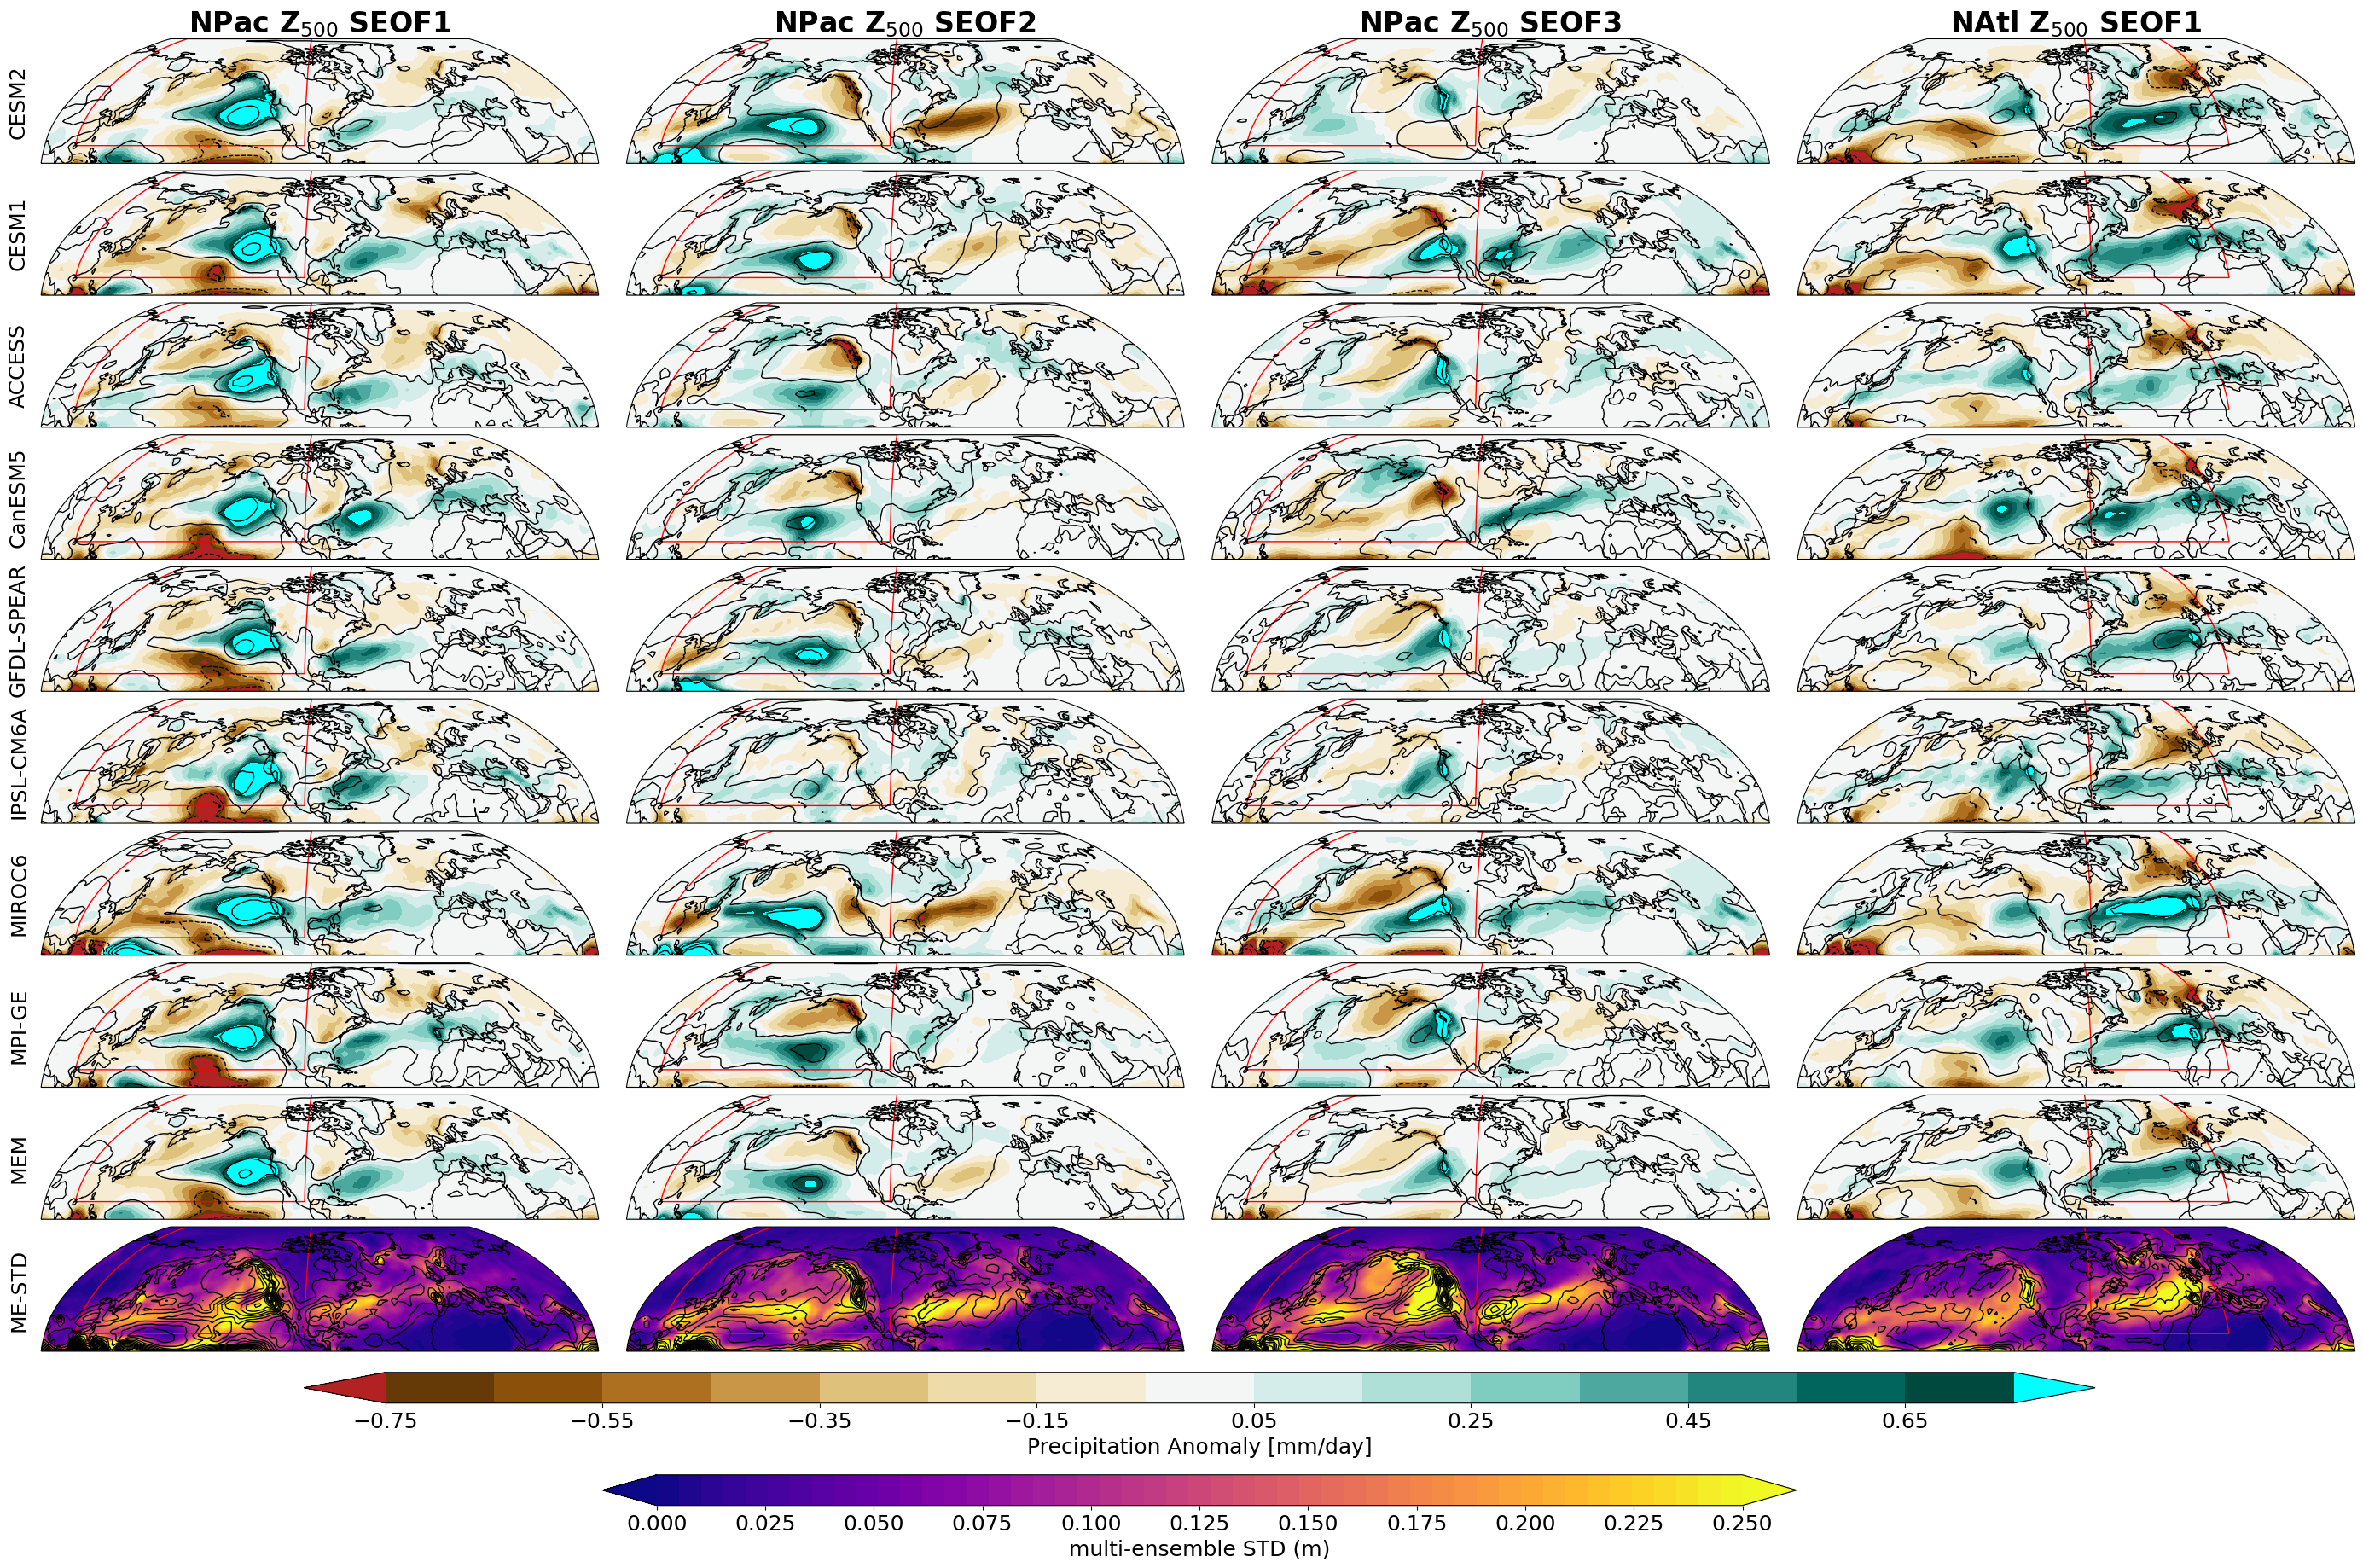

In [5]:
#plot data
fig,axs = PP.subplots(10,4,figsize=(35,20), subplot_kw={'projection': ccrs.Robinson(central_longitude=270)})
e=[-180, 180,10,90]


clevels = np.arange(-1,1.5,0.5)
levels = np.arange(-0.75,0.76,0.1)  # for precip
cmap = copy.deepcopy(mpl.cm.BrBG)
cmap.set_over('cyan')
cmap.set_under('firebrick')


levelsS = np.linspace(0,0.25)
levelsS2 = np.linspace(0,2)

cmap2=copy.deepcopy(mpl.cm.plasma)



# define 2d lat and lon points for ploting sig locs
lons=lon
lats=lat
lon2d,lat2d = np.meshgrid(lons,lats)


ii=-1
for model in models:
    ii=ii+1
    offset=1921-syear[ii]

    eof_T='_F1bdata_zgNPac'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_npac = np.ma.MaskedArray(**npz)*86400
    
    
    eof_T='_F1bdata_zgNAt'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_nat = np.ma.MaskedArray(**npz)*86400
    
    eof_T='_FS1bdata_zgNPac'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_npacC = np.ma.MaskedArray(**npz)
    
    
    eof_T='_FS1bdata_zgNAt'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_natC = np.ma.MaskedArray(**npz)
        
    if ii==0:
        data_z500_npac=data_z500_npac*1000
        data_z500_nat=data_z500_nat*1000
        data_z500_npacC=data_z500_npacC*1000
        data_z500_natC=data_z500_natC*1000    

    cnt=0
    ii2=-1
    for i in range(3): 

        ii2=ii2+1
        # grab early data
        cdataE,clons = add_cyclic_point(data_z500_npac[i,0+offset:10+offset,...].mean(axis=0),lons)
        # grab late data
        cdataL,clons = add_cyclic_point(data_z500_npac[i,164+offset:174+offset,...].mean(axis=0),lons)

        #plot difference in colour and early in contours
        cplt = axs[ii,i].contourf(clons,lats,cdataL, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extent=e, extend='both')   
        cpltc = axs[ii,i].contour(clons,lats,cdataE, transform=ccrs.PlateCarree(), levels=clevels, extent=e, colors='k', linewidths=1.0)

        axs[ii,i].coastlines()
        #axs[ii,i].set_ylim(-90,90)
        axs[ii,i].set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())

        cdataE_tot[ii,ii2,:,:]=cdataE
        cdataL_tot[ii,ii2,:,:]=cdataL
    
    for i in range(1): 
        ii2=ii2+1
        # grab early data
        cdataE,clons = add_cyclic_point(data_z500_nat[i,0+offset:10+offset,...].mean(axis=0),lons)
        # grab late data
        cdataL,clons = add_cyclic_point(data_z500_nat[i,164+offset:174+offset,...].mean(axis=0),lons)

        #plot difference in colour and early in contours
        cplt = axs[ii,i+3].contourf(clons,lats,cdataL, transform=ccrs.PlateCarree(), levels=levels, extent=e, cmap=cmap, extend='both')   
        cpltc = axs[ii,i+3].contour(clons,lats,cdataE, transform=ccrs.PlateCarree(), levels=clevels, extent=e, colors='k', linewidths=1.0)

        axs[ii,i+3].coastlines()
        #axs[ii,i+3].set_ylim(-90,90)
        axs[ii,i+3].set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())
 
        cdataE_tot[ii,ii2,:,:]=cdataE
        cdataL_tot[ii,ii2,:,:]=cdataL



ii=8
ii2=-1
for i in range(4): 
        ii2=ii2+1

        cdataE=np.mean(cdataE_tot[:,ii2,:,:],axis=0)
        cdataL=np.mean(cdataL_tot[:,ii2,:,:],axis=0)

        #plot difference in colour and early in contours
        cplt = axs[ii,i].contourf(clons,lats,cdataL, transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extent=e, extend='both')   
        cpltc = axs[ii,i].contour(clons,lats,cdataE, transform=ccrs.PlateCarree(), levels=clevels, extent=e, colors='k', linewidths=1.0)

        axs[ii,i].coastlines()
        #axs[ii,i].set_ylim(-90,90)
        axs[ii,i].set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())


PP.subplots_adjust(hspace=0.05,wspace=0.05)
cticks = np.linspace(-1,1,21)
cbar_ax = fig.add_axes([0.213, 0.08, 0.6, 0.018])
cbar = fig.colorbar(cplt, cax=cbar_ax, orientation='horizontal', ticks=levels[::2])
cbar.set_label('Precipitation Anomaly [mm/day]',fontsize=18)
cbar.ax.tick_params(labelsize=18)


ii=9
ii2=-1
for i in range(4): 
        ii2=ii2+1

        diff=cdataL_tot
        diff2=np.std(diff[:,ii2,:,:],axis=0)
        diff3=np.std(cdataE_tot[:,ii2,:,:],axis=0)

        #plot difference in colour and early in contours
        cplt = axs[ii,i].contourf(clons,lats,diff2, transform=ccrs.PlateCarree(), levels=levelsS, cmap=cmap2, extent=e, extend='both')   
        cpltc = axs[ii,i].contour(clons,lats,diff3, transform=ccrs.PlateCarree(), levels=levelsS2, extent=e, colors='k', linewidths=1.0)

        axs[ii,i].coastlines()
        #axs[ii,i].set_ylim(-90,90)
        axs[ii,i].set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())

PP.text(-0.04,0.5,models_title[0], rotation=90, fontsize=18, ha='center', va='center', transform=axs[0,0].transAxes)
PP.text(-0.04,0.5,models_title[1], rotation=90, fontsize=18, ha='center', va='center', transform=axs[1,0].transAxes)
PP.text(-0.04,0.5,models_title[2], rotation=90, fontsize=18, ha='center', va='center', transform=axs[2,0].transAxes)
PP.text(-0.04,0.5,models_title[3], rotation=90, fontsize=18, ha='center', va='center', transform=axs[3,0].transAxes)
PP.text(-0.04,0.5,models_title[4], rotation=90, fontsize=18, ha='center', va='center', transform=axs[4,0].transAxes)
PP.text(-0.04,0.5,models_title[5], rotation=90, fontsize=18, ha='center', va='center', transform=axs[5,0].transAxes)
PP.text(-0.04,0.5,models_title[6], rotation=90, fontsize=18, ha='center', va='center', transform=axs[6,0].transAxes)
PP.text(-0.04,0.5,models_title[7], rotation=90, fontsize=18, ha='center', va='center', transform=axs[7,0].transAxes)
PP.text(-0.04,0.5,'MEM', rotation=90, fontsize=18, ha='center', va='center', transform=axs[8,0].transAxes)
PP.text(-0.04,0.5,'ME-STD', rotation=90, fontsize=18, ha='center', va='center', transform=axs[9,0].transAxes)



axs[0,0].set_title('NPac Z$_{500}$ SEOF1', fontsize=24, weight='bold')
axs[0,1].set_title('NPac Z$_{500}$ SEOF2', fontsize=24, weight='bold')
axs[0,2].set_title('NPac Z$_{500}$ SEOF3', fontsize=24, weight='bold')
axs[0,3].set_title('NAtl Z$_{500}$ SEOF1', fontsize=24, weight='bold')






cticks = np.linspace(0,0.25,11)
cbar_ax = fig.add_axes([0.313, 0.02, 0.4, 0.018])
cbar = fig.colorbar(cplt, cax=cbar_ax, orientation='horizontal', ticks=cticks)
cbar.set_label('multi-ensemble STD (m)',fontsize=18)
cbar.ax.tick_params(labelsize=18)


# draw NPac Bnds

lat_range=[20,90]
lon_range=[110,260]
lat_height = lat_range[-1]-lat_range[0]
lon_width = lon_range[-1]-lon_range[0]

for i in range(3):
    for j in range(10):

        # NPac bnds
        axs[j,i].add_patch(mpatches.Rectangle(xy=[lon_range[0],lat_range[0]], width=lon_width, height=lat_height,\
                                edgecolor='red',\
                                linewidth=1,\
                                alpha=1,\
                                fill=False,\
                                transform=ccrs.PlateCarree()))

# draw NAtl Bnds

lat_range=[20,90]
lon_range=[280,10]

lat_height = lat_range[-1]-lat_range[0]
lon_width = lon_range[-1]-lon_range[0]+360

for i in range(1):
    for j in range(10):
        # NAtl bnds
        axs[j,i+3].add_patch(mpatches.Rectangle(xy=[lon_range[0],lat_range[0]], width=lon_width, height=lat_height,\
                                edgecolor='red',\
                                linewidth=1,\
                                alpha=1,\
                                fill=False,\
                                transform=ccrs.PlateCarree()))

outputdir2='/glade/work/nmaher/SEOF_output/figs_final/revision/'
PP.savefig(outputdir2+'FigureS5.png', dpi=300, bbox_inches='tight')
PP.show()
